In [74]:
import numpy as np
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.optimize import bisect

In [75]:
def y1(x):
    return 1.2*x**6 - 14*x**5 +5.2*x**4-8.3*x**3+x+2

def y2(x):
    return 1/x**3

arr = np.linspace(0, 10, 100_000)
y1_res = []

for x in arr:
    y1_res.append(y1(x))

In [76]:
y1_val = np.max(np.abs(y1_res))

x = arr[y1_res.index(np.max(y1_res))]

In [77]:
M = y1_val

def f(L):
    return abs(y2(L))-M

a = 1e10

print('a: ', f(a))

b = 1e-10

print('b: ', f(b))

L = bisect(f=f, a=a, b=b)

print(L)

a:  -165990.10550174062
b:  9.999999999999999e+29
0.01819586054506814


In [78]:
def z(x, y):
    return y1(x)*y2(y)

arr_x, arr_y = np.meshgrid(
    np.linspace(0, 10, 5000),
    np.linspace(L, 10, 5000))
arr_z = z(arr_x, arr_y)

In [79]:
arr_y = np.where(arr_y > 0.01, arr_y, np.nan)
arr_y_log = np.log10(arr_y)

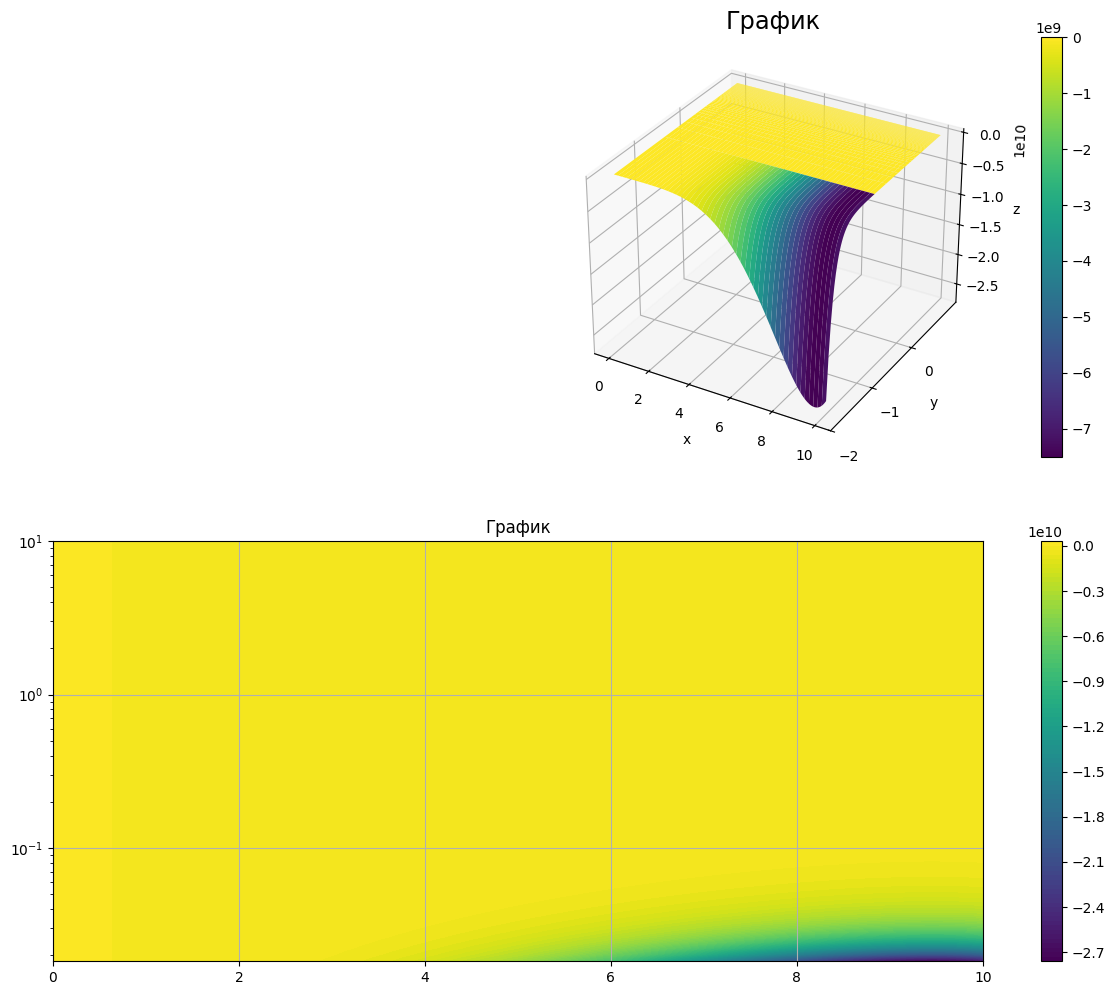

In [80]:
fig = plt.figure(figsize=(15, 12))

ax = fig.add_subplot(211, projection='3d')
surf = ax.plot_surface(arr_x, arr_y_log, arr_z, cmap='viridis')
fig.colorbar(surf)
y_ticks = np.array([0.01, 0.1, 1])
ax.set_yticks(np.log10(y_ticks))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.title('График', size='xx-large')

ax_2 = fig.add_subplot(212)
color_levels = 100
c_plt = ax_2.contourf(arr_x, arr_y, arr_z, color_levels)
fig.colorbar(c_plt)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.yscale('log')
plt.title('График')
plt.grid(True)

# Задание 2

In [81]:
def z(x, y):
    return y1(x)*y1(y)

arr_x, arr_y = np.meshgrid(
    np.linspace(0, 10, 5000),
    np.linspace(0, 10, 5000)
    )
arr_z = z(arr_x, arr_y)

level_high = np.max(arr_z)-0.25*(np.max(arr_z)-np.min(arr_z))
level_low = np.min(arr_z)+0.25*(np.max(arr_z)-np.min(arr_z))



Text(0.5, 1.0, 'График контурной плоскости с линиями уровня')

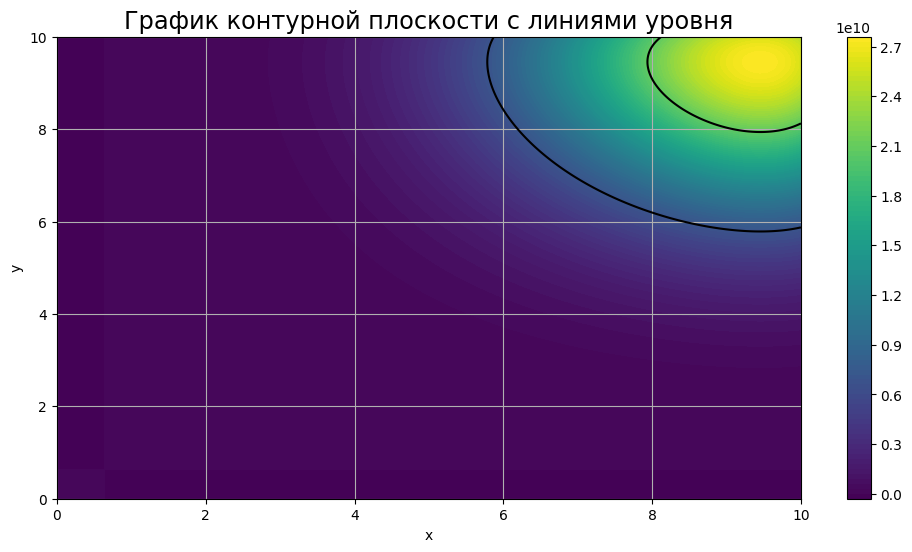

In [ ]:
plt.figure(figsize=(12, 6))
color_levels = 100
plt.contourf(arr_x, arr_y, arr_z, color_levels)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.contour(arr_x, arr_y, arr_z, levels=[level_low, level_high], colors='black')
plt.grid(True)
plt.title('График контурной плоскости с линиями уровня', size='xx-large')